In [8]:
# definition of the neural network
import torch
from phd_laboratory import neuralnet

class NeuralNet(neuralnet.NNTemplate):
    def __init__(self):
        super(NeuralNet, self).__init__()
        self.net = torch.nn.Sequential(
            # opening layer
            torch.nn.Sequential(
                torch.nn.Linear(2, 128),
                torch.nn.SiLU(),
            ),
            # body layers
            torch.nn.Sequential(
                torch.nn.Linear(128, 128),
                torch.nn.SiLU(),
                torch.nn.Linear(128, 128),
                torch.nn.SiLU(),
                torch.nn.Linear(128, 128),
                torch.nn.SiLU(),
            ),
            # closing layer
            torch.nn.Sequential(
                torch.nn.Linear(128, 1),
                #torch.nn.Softplus(beta=1)
            ),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # calcolo lo score function
        score: torch.Tensor = self.net(x).exp()  # (n_samples, 1)
        return score.squeeze(1)  # (n_samples,)

In [9]:
def V(r: torch.Tensor) -> torch.Tensor:
    # r: (n_samples,)
    return (r**2-1)**2
def objective_density(x: torch.Tensor) -> torch.Tensor:
    # x: (n_samples, n_dim)
    return (-2*V(torch.norm(x, dim=1))).exp()

In [18]:
class TrainLoss(torch.nn.Module):
    def __init__(self):
        super(TrainLoss, self).__init__()

    def forward(self, NNmodel: NeuralNet, batch: tuple[torch.Tensor]) -> torch.Tensor:
        """
        # batch: (inputs, labels)
        # L2 loss of the model
        weights = [param for param in NNmodel.net.parameters() if param.requires_grad]
        regularization = 0.0
        for w in weights:
            regularization = regularization + torch.mean(torch.pow(w, 2))
        regularization /= len(weights)
        # Lu loss computation
        sub_batch = batch[0][torch.rand(batch[0].shape[0])<0.0]
        Lu = torch.zeros(sub_batch.shape[0], device=sub_batch.device, dtype=sub_batch.dtype)
        if sub_batch.shape[0]>0:
            Lu = self.FKmodel.u_t(lambda y,_: NNmodel(y), sub_batch, 0.0)
        Lu = torch.pow(Lu, 2).mean()
        """
        # density comparison loss
        y = NNmodel(batch[0])
        solution = objective_density(batch[0]).unsqueeze(1)  # (n_samples, 1)
        L2_error = torch.nn.functional.mse_loss(solution, y.unsqueeze(1))
        #L2_error = torch.pow(solution - y, 2).mean()
        return L2_error # torch.pow(Lu, 2).mean() + L2_error  # + 1e-2 * regularization

In [19]:
NN = NeuralNet()
myloss = TrainLoss()
optimizer = torch.optim.AdamW(NN.parameters(), lr=1e-4)
loss_history = []
for i in range(5000):
    x = torch.rand(2048, 2) * 4 - 2
    y = objective_density(x)
    pred = NN(x)
    loss = myloss(NN, (x, y))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

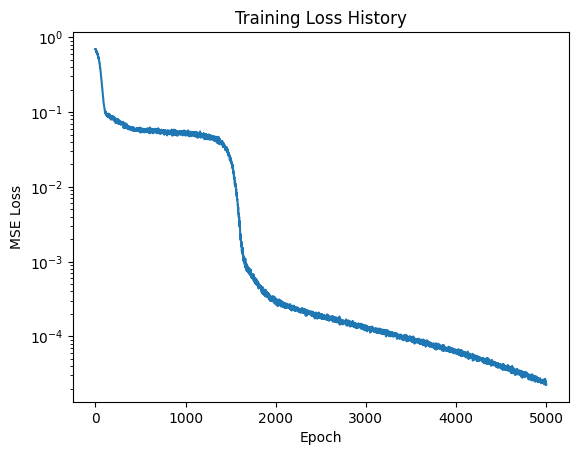

In [20]:
# show loss history
import matplotlib.pyplot as plt
plt.plot(loss_history)
plt.yscale('log')
plt.title("Training Loss History")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

In [ ]:
from phd_laboratory.differential.functions import nabla_at
import torch

# scelgo f: 
def f(x):
    return torch.sin(x[0]) * torch.cos(x[1])
def df(x):
    return torch.stack([
        torch.cos(x[:, 0]) * torch.cos(x[:, 1]),
        -torch.sin(x[:, 0]) * torch.sin(x[:, 1])
    ], dim=1)

x = torch.rand((10, 2)) * 4 - 2
nabla = nabla_at(f, x)
print("Input x:")
print(x.shape)
print(x)
print("Nabla of f at x:")
print(nabla.shape)
print(nabla)
print("Analytical gradient df at x:")
print(df(x))

Input x:
torch.Size([10, 2])
tensor([[ 0.7673,  0.6785],
        [-0.7479,  1.4124],
        [-0.0217,  1.0937],
        [-0.2180,  1.8684],
        [ 1.0311,  0.5421],
        [ 1.6903,  1.7915],
        [ 1.3995, -0.1915],
        [-0.2309,  0.4750],
        [ 1.4977, -1.7741],
        [-0.6043, -0.7434]], requires_grad=True)
Nabla of f at x:
torch.Size([10, 2])
tensor([[ 0.5603, -0.4357],
        [ 0.1156,  0.6716],
        [ 0.4591,  0.0193],
        [-0.2863,  0.2068],
        [ 0.4402, -0.4426],
        [ 0.0261, -0.9688],
        [ 0.1673,  0.1875],
        [ 0.8657,  0.1047],
        [-0.0147,  0.9768],
        [ 0.6058, -0.3846]], grad_fn=<ViewBackward0>)
Analytical gradient df at x:
tensor([[ 0.5603, -0.4357],
        [ 0.1156,  0.6716],
        [ 0.4591,  0.0193],
        [-0.2863,  0.2068],
        [ 0.4402, -0.4426],
        [ 0.0261, -0.9688],
        [ 0.1673,  0.1875],
        [ 0.8657,  0.1047],
        [-0.0147,  0.9768],
        [ 0.6058, -0.3846]], grad_fn=<StackBac

In [3]:
from phd_laboratory.differential.functions import nabla_at
import torch
from torch import nn

# scelgo f: 
net = nn.Sequential(
    nn.Linear(2, 128),
    nn.SiLU(),
    nn.Linear(128, 3),
)
def f(x):
    return net(x)

x = torch.rand((10, 2)) * 4 - 2
nabla = nabla_at(f, x)
print("Input x:")
print(x.shape)
print(x)
print("Nabla of f at x:")
print(nabla.shape)
print(nabla)

Input x:
torch.Size([10, 2])
tensor([[ 1.0502, -1.0942],
        [-1.4860, -1.7142],
        [ 1.9185, -1.6403],
        [-0.4222, -0.0138],
        [ 0.8391, -0.8603],
        [ 0.3207, -1.3843],
        [-1.3394,  1.8681],
        [-0.3016,  1.2263],
        [ 0.3819, -0.5479],
        [-0.6526,  0.2673]], requires_grad=True)
Nabla of f at x:
torch.Size([10, 3, 2])
tensor([[[ 0.0917,  0.2600],
         [ 0.0113,  0.0085],
         [ 0.0081,  0.0761]],

        [[ 0.2498,  0.3235],
         [ 0.1332,  0.0577],
         [ 0.1349, -0.0152]],

        [[ 0.0677,  0.2372],
         [-0.0055,  0.0192],
         [ 0.0061,  0.0892]],

        [[ 0.1696,  0.2655],
         [ 0.0749, -0.0503],
         [ 0.1437, -0.0419]],

        [[ 0.0959,  0.2607],
         [ 0.0158, -0.0049],
         [ 0.0190,  0.0653]],

        [[ 0.1500,  0.2970],
         [ 0.0521,  0.0463],
         [ 0.0153,  0.0605]],

        [[ 0.1667,  0.2254],
         [ 0.0569, -0.1450],
         [ 0.2963, -0.1337]],

       

In [6]:
import torch
from torch import nn

# N,6 -> N,1,6,6
net = nn.Sequential(
    nn.Linear(6, 128),
    nn.SiLU(),
    nn.Linear(128, 1*6*6),
)

def f(x):
    if x.ndim == 3:
        x = x.reshape(-1,6)
        x = net(x)
        x = x.reshape(-1,1,6,6)
        return x
    else:
        x = x.reshape(-1,6)
        x = net(x)
        x = x.reshape(-1,1,6,6)
        return x.squeeze(0)

x = torch.rand((8000, 6))

In [7]:
from torch.func import vmap, jacrev
from typing import Callable

class DivFMultiple:
    class DivF:
        def __init__(self, fun: Callable[[torch.Tensor], torch.Tensor], outer_dim: torch.Size, vectorized: bool = False):
            self.fun = fun
            self.outer_dim = outer_dim
            self.vectorized = vectorized

        def __call__(self, x: torch.Tensor) -> torch.Tensor:
            df_x: torch.Tensor
            if self.vectorized:
                in_dim = x.shape[1:]
                df_x = vmap(jacrev(self.fun))(x)  # (N,b1,...,a1,...,a1,...)
                df_x = df_x.reshape(-1, self.outer_dim.numel(), in_dim.numel(), in_dim.numel())  # (N,B,A,A)
                divf_x = torch.einsum("...jii->...j", df_x)  # (N,b1,...)
                divf_x = divf_x.reshape(-1, *self.outer_dim)  # (N,b1,...)
            else:
                in_dim = x.shape
                df_x = jacrev(self.fun)(x)  # (N,b1,...,a1,...,a1,...)
                df_x = df_x.reshape(self.outer_dim.numel(), in_dim.numel(), in_dim.numel())  # (N,B,A,A)
                divf_x = torch.einsum("jii->j", df_x)  # (N,b1,...)
                divf_x = divf_x.reshape(*self.outer_dim)  # (N,b1,...)
            return divf_x

    def __init__(self, order: int, fun: Callable[[torch.Tensor], torch.Tensor], outer_dim: torch.Size, vectorized: bool = False):
        self.order = order
        self.fun = fun  # take in_dim and return outer_dim + order x in_dim
        self.outer_dim = outer_dim
        self.vectorized = vectorized

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        mult_divf = self.fun
        if self.vectorized:
            in_dim = x.shape[1:]
        else:
            in_dim = x.shape
        for i in range(1,self.order):
            current_outer_dim = self.outer_dim + (self.order-i) * in_dim
            mult_divf = DivFMultiple.DivF(mult_divf, current_outer_dim)
        return DivFMultiple.DivF(mult_divf, self.outer_dim, self.vectorized)(x)

DivFMultiple(2, f, torch.Size([1]), True)(x).shape

torch.Size([8000, 1])

In [ ]:
from torch.func import vmap, jacrev
from typing import Callable

class NablaFMultiple:
    class NablaF:
        def __init__(self, fun: Callable[[torch.Tensor], torch.Tensor], outer_dim: torch.Size, vectorized: bool = False):
            self.fun = fun
            self.outer_dim = outer_dim
            self.vectorized = vectorized

        def __call__(self, x: torch.Tensor) -> torch.Tensor:
            df_x: torch.Tensor
            if self.vectorized:
                in_dim = x.shape[1:]
                df_x = vmap(jacrev(self.fun))(x)  # (N,b1,...,a1,...,a1,...)
                df_x = df_x.reshape(-1, self.outer_dim.numel(), in_dim.numel(), in_dim.numel())  # (N,B,A,A)
                divf_x = torch.einsum("...jii->...j", df_x)  # (N,b1,...)
                divf_x = divf_x.reshape(-1, *self.outer_dim)  # (N,b1,...)
            else:
                in_dim = x.shape
                df_x = jacrev(self.fun)(x)  # (N,b1,...,a1,...,a1,...)
                df_x = df_x.reshape(self.outer_dim.numel(), in_dim.numel(), in_dim.numel())  # (N,B,A,A)
                divf_x = torch.einsum("jii->j", df_x)  # (N,b1,...)
                divf_x = divf_x.reshape(*self.outer_dim)  # (N,b1,...)
            return divf_x

    def __init__(self, order: int, fun: Callable[[torch.Tensor], torch.Tensor], outer_dim: torch.Size, vectorized: bool = False):
        self.order = order
        self.fun = fun  # take in_dim and return outer_dim + order x in_dim
        self.outer_dim = outer_dim
        self.vectorized = vectorized

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        mult_divf = self.fun
        if self.vectorized:
            in_dim = x.shape[1:]
        else:
            in_dim = x.shape
        for i in range(1,self.order):
            current_outer_dim = self.outer_dim + (self.order-i) * in_dim
            mult_divf = DivFMultiple.DivF(mult_divf, current_outer_dim)
        return DivFMultiple.DivF(mult_divf, self.outer_dim, self.vectorized)(x)

DivFMultiple(2, f, torch.Size([1]), True)(x).shape

In [2]:
f_x, J1_x, J2_x = diff.nabla(Func(f))(x, True)

assert J1_x.shape == expJ1_x.shape
assert torch.max(J1_x - expJ1_x) < eps
assert expJ2_x.shape == J2_x.shape
assert torch.max(J2_x - expJ2_x) < eps